# Exploratory Data Analysis!
In this notebook, I will load a few audio files from my dataset with librosa, just to see what we're working with.

In [1]:
# data anlysis libraries
import pandas as pd
import numpy as np

# file parsing libraries
import re
from pathlib import Path

# data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# glob
from glob import glob

# audio processing libraries
import librosa

In [2]:
# save all audio files in the raw data directory
audio_files = glob("../data/raw/*.wav")
print(f'Top 5 files: {audio_files[:5]}')

Top 5 files: ['../data/raw\\B_ANI01_MC_FN_SIM01_101.wav', '../data/raw\\B_ANI01_MC_FN_SIM01_102.wav', '../data/raw\\B_ANI01_MC_FN_SIM01_103.wav', '../data/raw\\B_ANI01_MC_FN_SIM01_301.wav', '../data/raw\\B_ANI01_MC_FN_SIM01_302.wav']


In [3]:
# save numpy array for audio file (y) and sample rate (sr)
y, sr = librosa.load(audio_files[0])
print(f'y: {y[:10]}')
print(f"Shape y: {y.shape}, Sample Rate: {sr}")

y: [-9.1832391e-08 -2.5374214e-07 -1.8483684e-07  1.2441542e-07
  3.0783772e-07  1.5577265e-07 -1.7498628e-07 -3.3151454e-07
 -1.2974749e-07  2.2750578e-07]
Shape y: (50308,), Sample Rate: 22050


Text(0.5, 1.0, 'Raw Audio Signal')

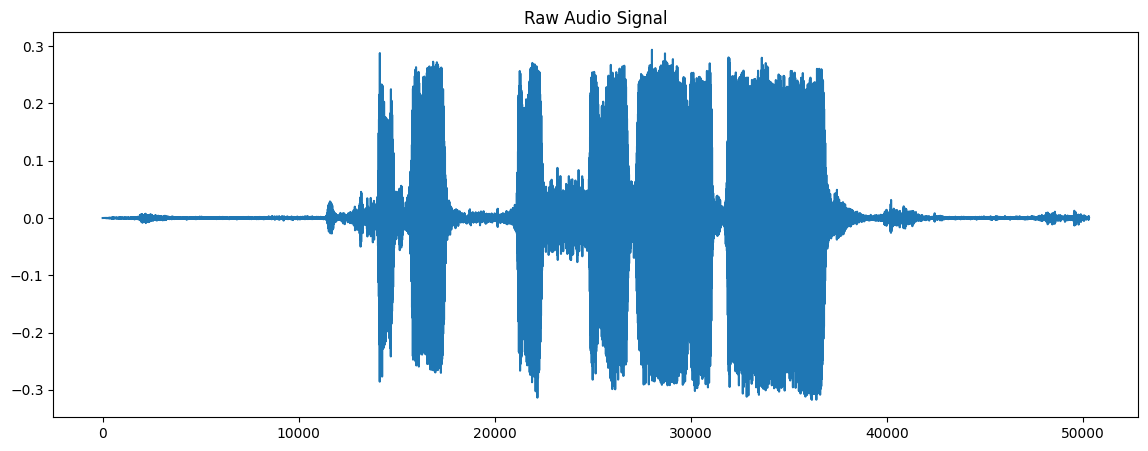

In [4]:
# plot the raw audio signal using pandas and matplotlib
pd.Series(y).plot(figsize=(14, 5))
plt.title("Raw Audio Signal")

y_trimmed: [ 0.00150274 -0.0031554  -0.00524788 -0.00509775 -0.00440349 -0.00420725
 -0.00379539 -0.00162763  0.00260786  0.00689141]


Text(0.5, 1.0, 'Trimmed Audio Signal')

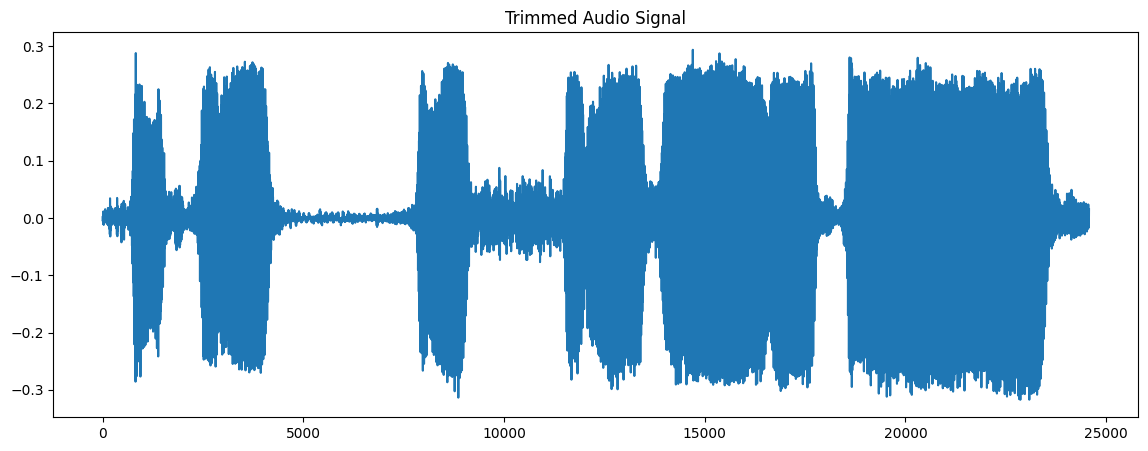

In [5]:
# trim out silence from the beginning and end of the audio signal
y_trimmed, _ = librosa.effects.trim(y, top_db=20)
print(f'y_trimmed: {y_trimmed[:10]}')
pd.Series(y_trimmed).plot(figsize=(14, 5))
plt.title("Trimmed Audio Signal")

Text(0.5, 1.0, 'Zoomed In Trimmed Audio Signal')

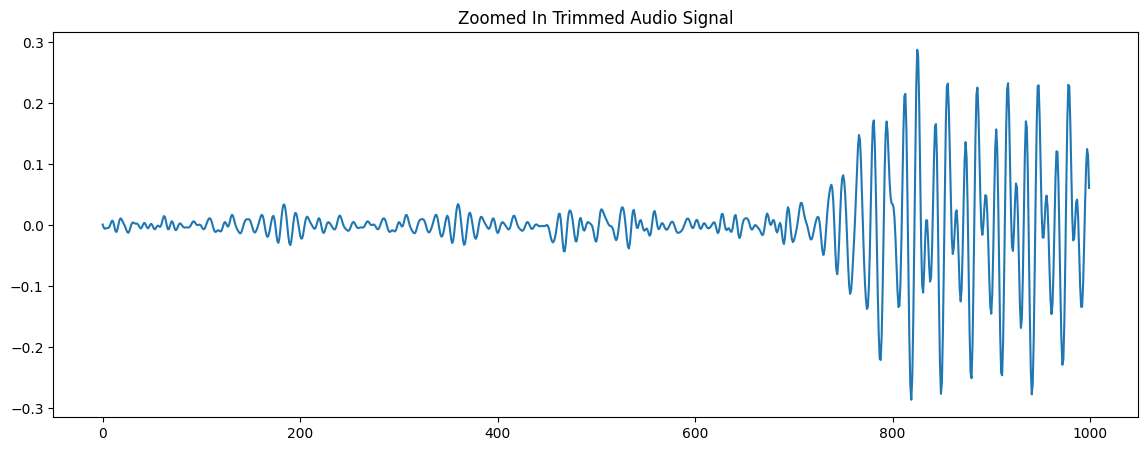

In [6]:
# zoom in on the first 1000 samples of the trimmed audio signal
pd.Series(y_trimmed[:1000]).plot(figsize=(14, 5))
plt.title("Zoomed In Trimmed Audio Signal")


**Fourier transform** - Plots frequency of audio sample to intensity (instead of intensity vs time)

(1025, 49)


Text(0.5, 1.0, 'Spectrogram (dB)')

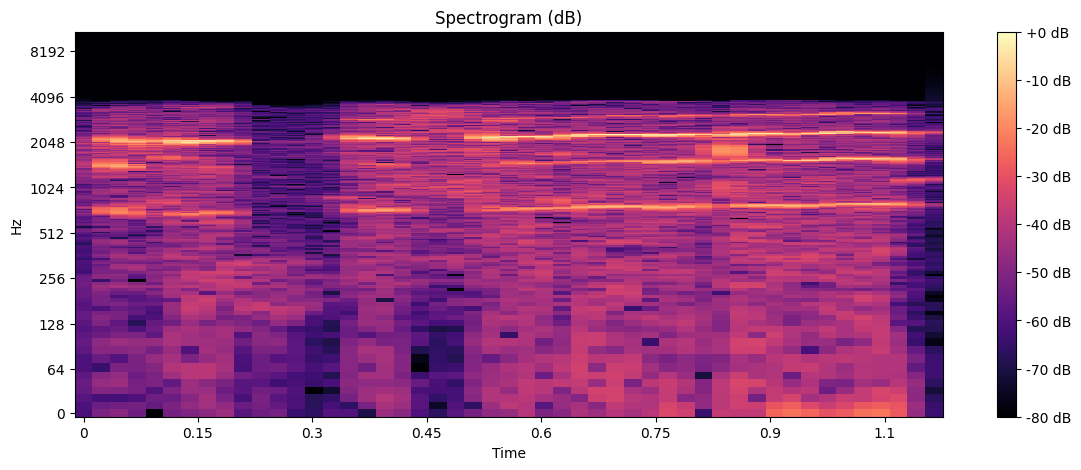

In [7]:
# short-time fourier transform (STFT) to get the spectrogram of the audio signal
D = librosa.stft(y_trimmed, n_fft=2048, hop_length=512)

# convert the amplitude to decibels
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
print(S_db.shape)
# plot the spectrogram using librosa's display module
plt.figure(figsize=(14, 5))
librosa.display.specshow(S_db, sr=sr, hop_length=512, x_axis="time", y_axis="log")
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram (dB)")


**MELL Spectrogram** - Specialized spectrogram that uses a different, non-linear scale to match how humans actually perceive sound
- Humans are better at detecting differences between lower pitches than higher pitches
- We also perceive loudness logarithmically instead of linearly
- It basically "stretches" the low frequencies where humans are the most sensitive, and "compresses" the higher frequencies

In [8]:
# use librosa.feature.melspectrogram to get the mel spectrogram of the audio signal
S = librosa.feature.melspectrogram(y=y_trimmed, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
S_db_mel = librosa.power_to_db(S, ref=np.max)
print(S_db_mel.shape)

(128, 49)


Text(0.5, 1.0, 'Mel Spectrogram (dB)')

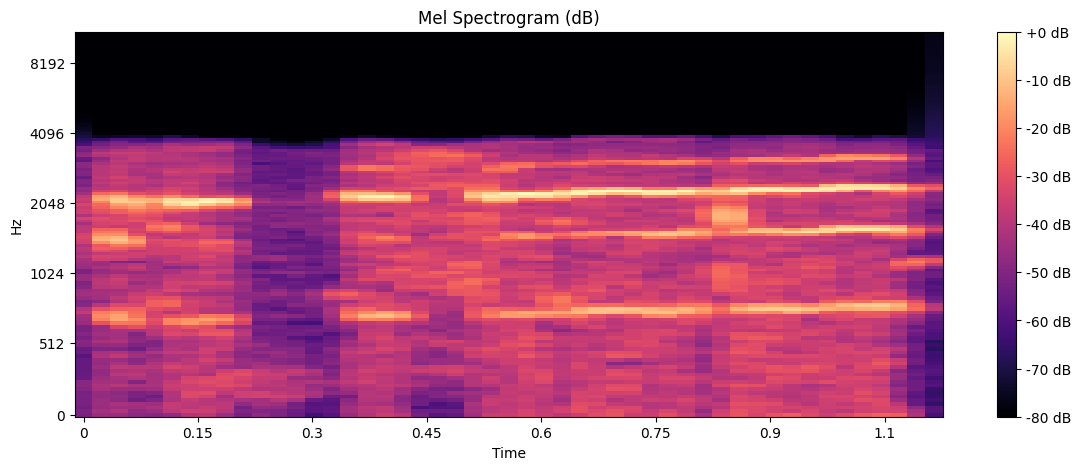

In [9]:
# plot the spectrogram of the audio signal
plt.figure(figsize=(14, 5))
librosa.display.specshow(S_db_mel, sr=sr, hop_length=512, x_axis="time", y_axis="mel")
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram (dB)")


## Spectrograms per class

### Brushing (B)
The first audio file was a bit low-quality, so I found a better quality audio clip from my dataset to analyze!

yb: [ 2.76001112e-04  3.05346912e-04  1.40080912e-04 -1.13482325e-04
 -3.82145459e-04 -5.49530087e-04 -5.33320999e-04 -3.46290268e-04
 -8.28914053e-05  1.27374558e-04]
Shape yb: (54210,), Sample Rate: 22050


Text(0.5, 1.0, 'Raw Audio Signal')

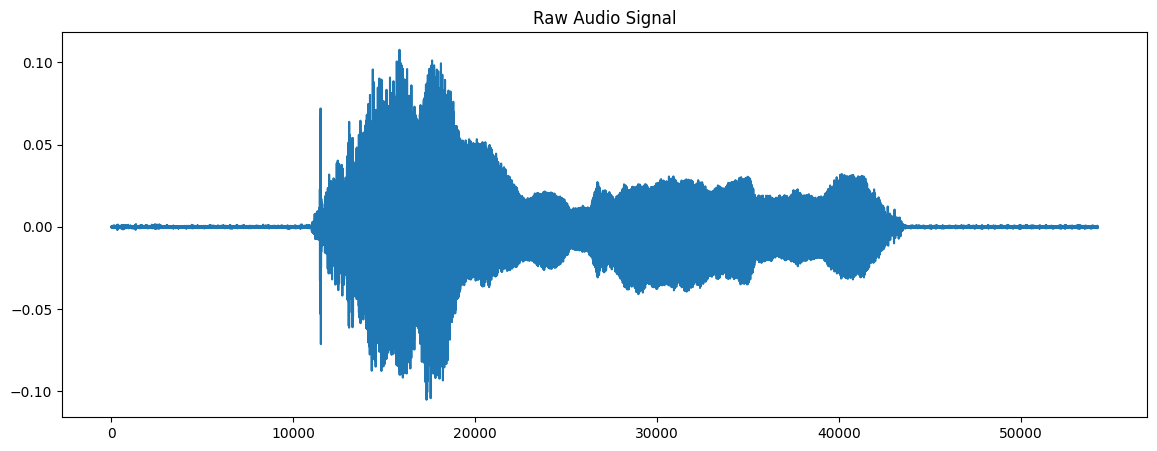

In [21]:
yb, sr2 = librosa.load("../data/raw/B_CAN01_EU_FN_GIA01_102.wav")
print(f'yb: {yb[:10]}')
print(f"Shape yb: {yb.shape}, Sample Rate: {sr2}")

# plot the raw audio signal using pandas and matplotlib
pd.Series(yb).plot(figsize=(14, 5))
plt.title("Raw Audio Signal")


yb_trimmed: [-6.4254727e-04 -5.3665170e-04 -3.8401532e-04 -2.0444959e-04
 -4.6828016e-05  2.7171562e-05 -1.5994403e-05 -1.4475330e-04
 -2.6585095e-04 -2.7941517e-04]


Text(0.5, 1.0, 'Trimmed Audio Signal')

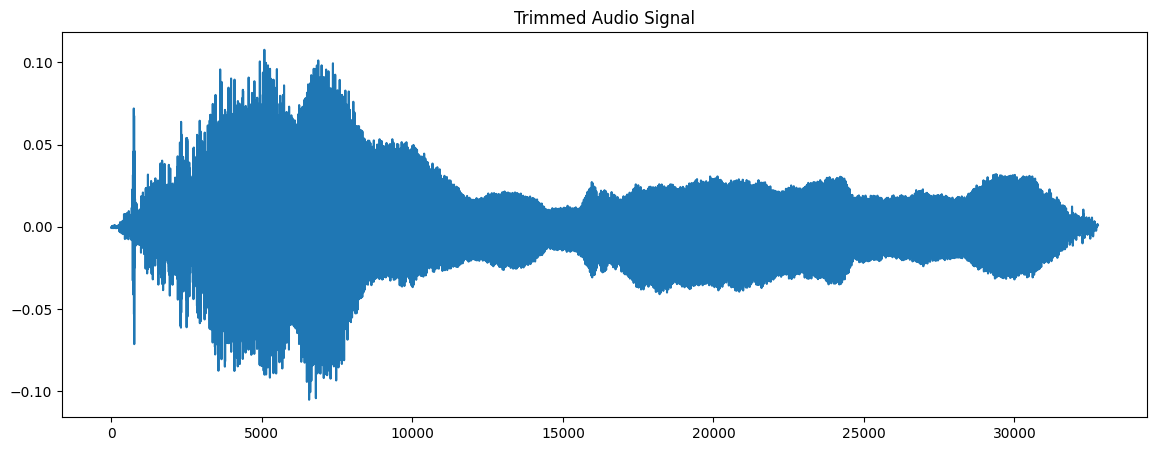

In [22]:
# trim out silence from the beginning and end of the audio signal
yb_trimmed, _ = librosa.effects.trim(yb, top_db=20)
print(f'yb_trimmed: {yb_trimmed[:10]}')
pd.Series(yb_trimmed).plot(figsize=(14, 5))
plt.title("Trimmed Audio Signal")

S_db2.shape:  (1025, 65)


Text(0.5, 1.0, 'Brushing Spectrogram (dB)')

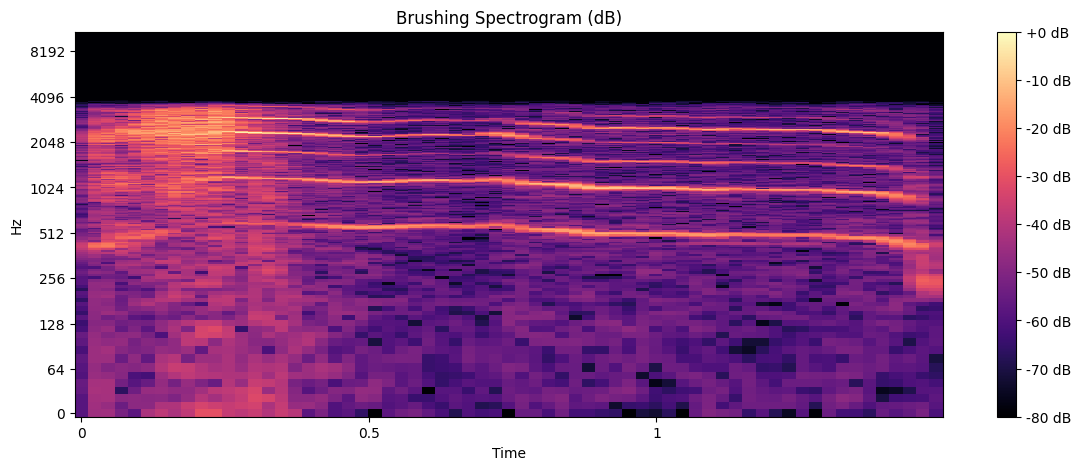

In [23]:
# fourier transform to get the spectrogram of the audio signal
D2 = librosa.stft(yb_trimmed, n_fft=2048, hop_length=512)
# convert the amplitude to decibels
S_db2 = librosa.amplitude_to_db(np.abs(D2), ref=np.max)
print("S_db2.shape: ", S_db2.shape)

# plot the spectrogram using librosa's display module
plt.figure(figsize=(14, 5))
librosa.display.specshow(S_db2, sr=sr2, hop_length=512, x_axis="time", y_axis="log")
plt.colorbar(format="%+2.0f dB")
plt.title("Brushing Spectrogram (dB)")


S_db_mel2.shape:  (128, 65)


Text(0.5, 1.0, 'Brushing Mel Spectrogram (dB)')

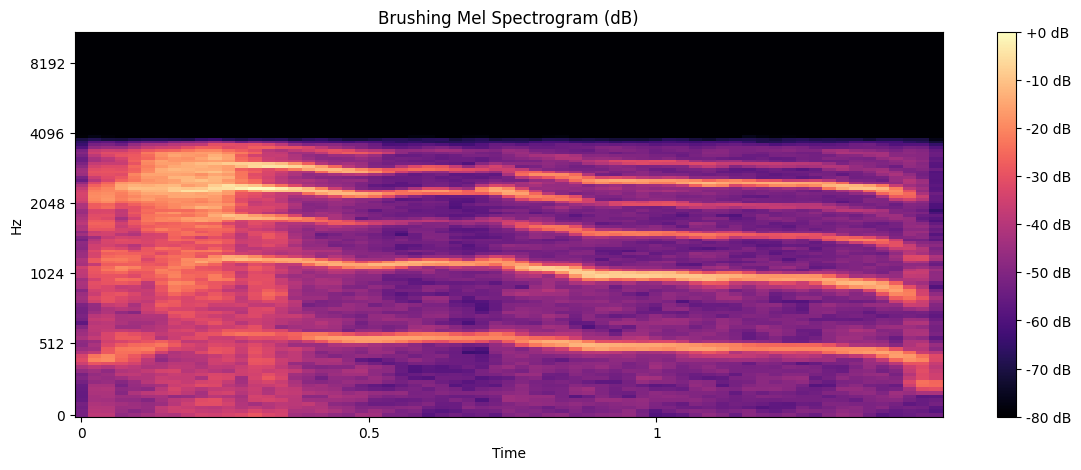

In [24]:
# use librosa.feature.melspectrogram to get the mel spectrogram of the audio signal
S2 = librosa.feature.melspectrogram(y=yb_trimmed, sr=sr2, n_fft=2048, hop_length=512, n_mels=128)
S_db_mel2 = librosa.power_to_db(S2, ref=np.max)
print("S_db_mel2.shape: ", S_db_mel2.shape)

# plot the spectrogram of the audio signal
plt.figure(figsize=(14, 5))
librosa.display.specshow(S_db_mel2, sr=sr2, hop_length=512, x_axis="time", y_axis="mel")
plt.colorbar(format="%+2.0f dB")
plt.title("Brushing Mel Spectrogram (dB)")

### Waiting for Food (F)

In [30]:
# Load an audio file with name Starting with 'F'
yf, sr3 = librosa.load("../data/raw/F_BLE01_EU_FN_DEL01_103.wav")
print(f'yf: {yf[:10]}')
print(f"Shape yf: {yf.shape}, Sample Rate: {sr3}")

yf: [-3.0891111e-05  5.6112178e-05  1.0745900e-04 -1.8542123e-06
 -2.2005574e-04 -4.1632890e-04 -4.5979786e-04 -3.0623653e-04
 -3.6863625e-05  2.0410985e-04]
Shape yf: (32965,), Sample Rate: 22050


Text(0.5, 1.0, 'Waiting for Food Mel Spectrogram (dB)')

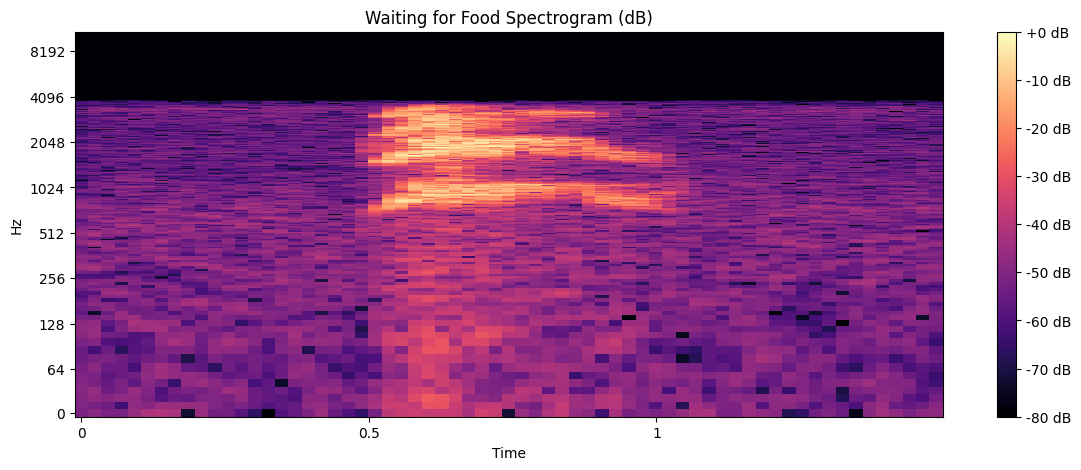

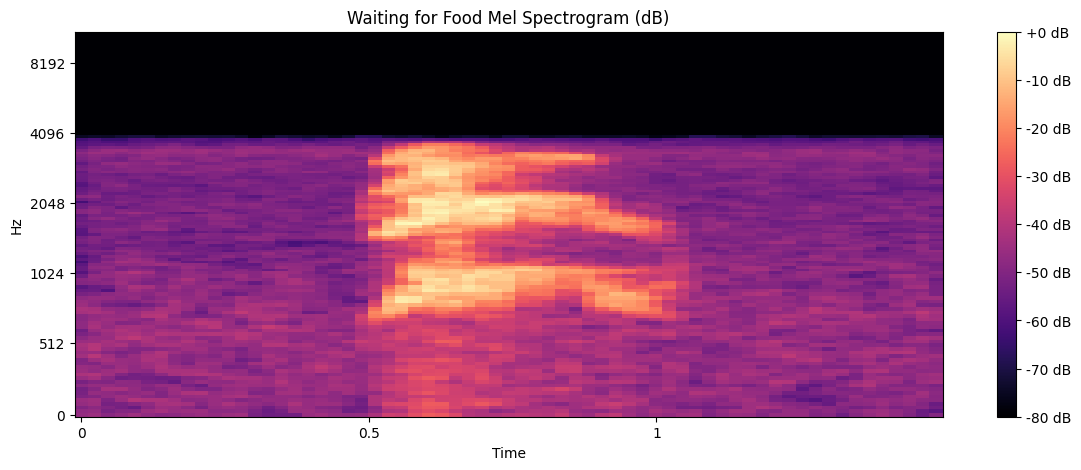

In [31]:
# create spectrogram and mel spectrogram for the 'waiting for food' audio file
D3 = librosa.stft(yf, n_fft=2048, hop_length=512)
S_db3 = librosa.amplitude_to_db(np.abs(D3), ref=np.max)
S3 = librosa.feature.melspectrogram(y=yf, sr=sr3, n_fft=2048, hop_length=512, n_mels=128)
S_db_mel3 = librosa.power_to_db(S3, ref=np.max)
plt.figure(figsize=(14, 5))
librosa.display.specshow(S_db3, sr=sr3, hop_length=512, x_axis="time", y_axis="log")
plt.colorbar(format="%+2.0f dB")
plt.title("Waiting for Food Spectrogram (dB)")

plt.figure(figsize=(14, 5))
librosa.display.specshow(S_db_mel3, sr=sr3, hop_length=512, x_axis="time", y_axis="mel")
plt.colorbar(format="%+2.0f dB")
plt.title("Waiting for Food Mel Spectrogram (dB)")

### Isolation In An Unfamiliar Environment (I)

Text(0.5, 1.0, 'Isolation Mel Spectrogram (dB)')

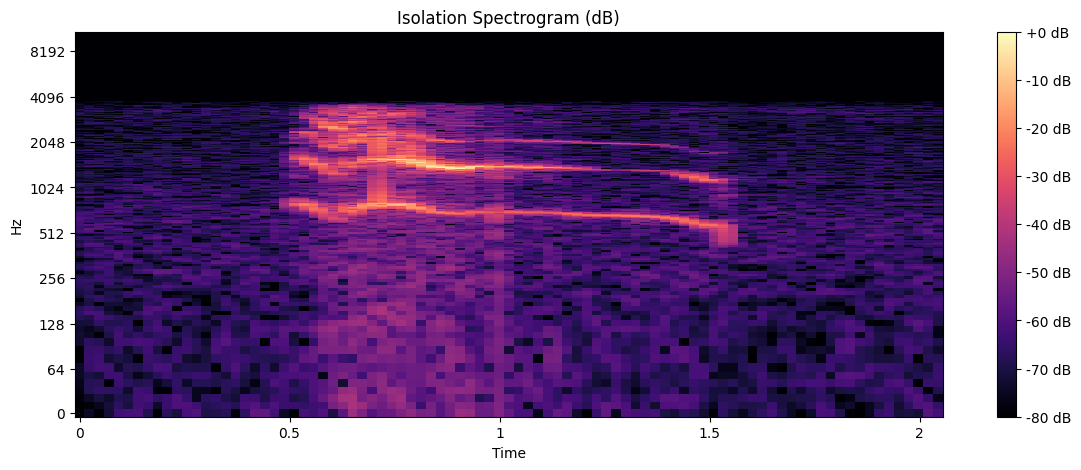

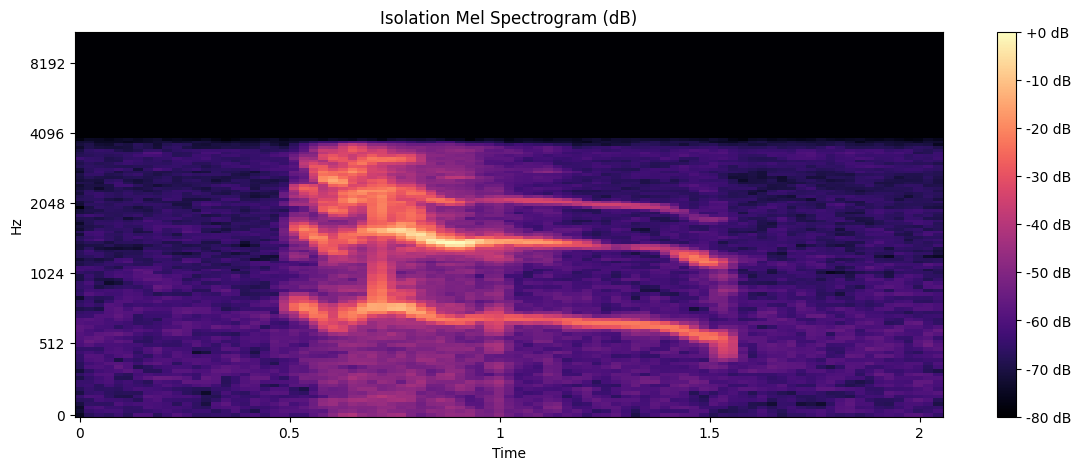

In [35]:
# load audio file with name starting with 'I' 
yi, sri = librosa.load("../data/raw/I_BLE01_EU_FN_DEL01_101.wav")

# create spectrograms and mel spectrograms
D4 = librosa.stft(yi, n_fft=2048, hop_length=512)
S_db4 = librosa.amplitude_to_db(np.abs(D4), ref=np.max)
S4 = librosa.feature.melspectrogram(y=yi, sr=sri, n_fft=2048, hop_length=512, n_mels=128)
S_db_mel4 = librosa.power_to_db(S4, ref=np.max)
plt.figure(figsize=(14, 5))
librosa.display.specshow(S_db4, sr=sri, hop_length=512, x_axis="time", y_axis="log")
plt.colorbar(format="%+2.0f dB")
plt.title("Isolation Spectrogram (dB)")
plt.figure(figsize=(14, 5))
librosa.display.specshow(S_db_mel4, sr=sri, hop_length=512, x_axis="time", y_axis="mel")
plt.colorbar(format="%+2.0f dB")
plt.title("Isolation Mel Spectrogram (dB)")

## Analyzing class distributions
Analysis and visualization for distributions between context, sex, breed, and vocalization counter.

The audio files in the dataset were named in the format C_NNNNN_BB_SS_OOOOO_RXX.wav, which has to be exploded as follows:
- C = emission context (values: B = brushing; F = waiting for food; I: isolation in an unfamiliar environment);
- NNNNN = cat’s unique ID;
- BB = breed (values: MC = Maine Coon; EU: European Shorthair);
- SS = sex (values: FI = female, intact; FN: female, neutered; MI: male, intact; MN: male, neutered);
- OOOOO = cat owner’s unique ID;
- R = recording session (values: 1, 2 or 3)
- XX = vocalization counter (values: 01..99)


In [48]:
def parse_filename(filepath):
    """Parse C_NNNNN_BB_SS_OOOOO_RXX.wav pattern"""
    filename = Path(filepath).stem
    
    # Flexible pattern: handles both _R01 and _01 formats
    pattern = r"^([BFI])_(\w{5})_([A-Z]{2})_([A-Z]{2})_(\w{5})_(\d{1,3})$"
    match = re.match(pattern, filename)
    
    if not match:
        print(f"Could not parse: {filename}")
        return None
    
    return {
        "filepath": filepath,
        "filename": filename + ".wav",
        "context": match.group(1),    # B/F/I
        "cat_id": match.group(2),     # 5-char ID
        "breed": match.group(3),      # MC/EU
        "sex": match.group(4),        # FI/FN/MI/MN
        "owner_id": match.group(5),   # 5-char owner ID
        "vocalization": int(match.group(6))  # 1-999
    }


In [52]:
# Parse all files
metadata = []
for fp in audio_files:
    parsed = parse_filename(fp)
    if parsed:
        metadata.append(parsed)

# Create DataFrame
df = pd.DataFrame(metadata)
print(f"\nSuccessfully parsed {len(df)} / {len(audio_files)} files")
print("\nFirst 5 rows:")
df.head()


Successfully parsed 440 / 440 files

First 5 rows:


,filepath,filename,context,cat_id,breed,sex,owner_id,vocalization
0,../data/raw\B_ANI01_MC_FN_SIM01_101.wav,B_ANI01_MC_FN_SIM01_101.wav,B,ANI01,MC,FN,SIM01,101
1,../data/raw\B_ANI01_MC_FN_SIM01_102.wav,B_ANI01_MC_FN_SIM01_102.wav,B,ANI01,MC,FN,SIM01,102
2,../data/raw\B_ANI01_MC_FN_SIM01_103.wav,B_ANI01_MC_FN_SIM01_103.wav,B,ANI01,MC,FN,SIM01,103
3,../data/raw\B_ANI01_MC_FN_SIM01_301.wav,B_ANI01_MC_FN_SIM01_301.wav,B,ANI01,MC,FN,SIM01,301
4,../data/raw\B_ANI01_MC_FN_SIM01_302.wav,B_ANI01_MC_FN_SIM01_302.wav,B,ANI01,MC,FN,SIM01,302


In [62]:
# === CONTEXT DISTRIBUTION ===
print("\n" + "="*120)
print("CONTEXT DISTRIBUTION (Experimental Conditions)")
print("="*120)
context_meows = df['context_label'].value_counts().sort_index()
context_cats = df.groupby('context_label')['cat_id'].nunique().sort_index()

for ctx in context_meows.index:
    meow_count = context_meows[ctx]
    cat_count = context_cats[ctx]
    meows_per_cat = meow_count / cat_count
    pct = meow_count / len(df) * 100
    print(f"  {ctx:25s}: {meow_count:3d} meows from {cat_count:2d} cats "
          f"({meows_per_cat:4.1f} meows/cat, {pct:5.1f}% of meows from entire dataset)")

# === BREED DISTRIBUTION ===
print("\n" + "="*120)
print("BREED DISTRIBUTION")
print("="*120)
breed_meows = df['breed_label'].value_counts()
breed_cats = df.groupby('breed_label')['cat_id'].nunique()

for breed in breed_meows.index:
    meow_count = breed_meows[breed]
    cat_count = breed_cats[breed]
    meows_per_cat = meow_count / cat_count
    pct = meow_count / len(df) * 100
    print(f"  {breed:25s}: {meow_count:3d} meows from {cat_count:2d} cats "
          f"({meows_per_cat:4.1f} meows/cat, {pct:5.1f}% of meows from entire dataset)")

# === SEX DISTRIBUTION ===
print("\n" + "="*120)
print("SEX/NEUTER STATUS DISTRIBUTION")
print("="*120)
sex_meows = df['sex_label'].value_counts()
sex_cats = df.groupby('sex_label')['cat_id'].nunique()

for sex in sex_meows.index:
    meow_count = sex_meows[sex]
    cat_count = sex_cats[sex]
    meows_per_cat = meow_count / cat_count
    pct = meow_count / len(df) * 100
    print(f"  {sex:25s}: {meow_count:3d} meows from {cat_count:2d} cats "
          f"({meows_per_cat:4.1f} meows/cat, {pct:5.1f}% of meows from entire dataset)")

# === CRITICAL: Check for cat ID leakage across contexts ===
print("\n" + "="*120)
print("CAT ID LEAKAGE CHECK (Same cats in multiple contexts?)")
print("="*120)
cats_per_context_count = df.groupby('cat_id')['context'].nunique()
multi_context_cats = cats_per_context_count[cats_per_context_count > 1].count()
total_cats = df['cat_id'].nunique()

print(f"  Total unique cats: {total_cats}")
print(f"  Cats appearing in MULTIPLE contexts: {multi_context_cats} ({multi_context_cats/total_cats*100:.1f}%)")
print(f"  Cats appearing in ONLY ONE context: {total_cats - multi_context_cats} ({(total_cats - multi_context_cats)/total_cats*100:.1f}%)")


CONTEXT DISTRIBUTION (Experimental Conditions)
  Brushing                 : 127 meows from 17 cats ( 7.5 meows/cat,  28.9% of meows from entire dataset)
  Isolation                : 221 meows from 17 cats (13.0 meows/cat,  50.2% of meows from entire dataset)
  Waiting for Food         :  92 meows from 15 cats ( 6.1 meows/cat,  20.9% of meows from entire dataset)

BREED DISTRIBUTION
  European Shorthair       : 252 meows from 11 cats (22.9 meows/cat,  57.3% of meows from entire dataset)
  Maine Coon               : 188 meows from 10 cats (18.8 meows/cat,  42.7% of meows from entire dataset)

SEX/NEUTER STATUS DISTRIBUTION
  Female, Neutered         : 277 meows from 12 cats (23.1 meows/cat,  63.0% of meows from entire dataset)
  Male, Neutered           :  76 meows from  4 cats (19.0 meows/cat,  17.3% of meows from entire dataset)
  Female, Intact           :  68 meows from  3 cats (22.7 meows/cat,  15.5% of meows from entire dataset)
  Male, Intact             :  19 meows from  2 cats 

Many cats appear in multiple contexts, which can show strong evidence that context influences the acoustic features of meows, and not just cat identity.

## Audio file duration distributions